# Quantum Statistical Potential

The YAML input file can be found at [input_file](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/QSP/input_files/QSP_cgs.yaml) and this notebook at [notebook](https://raw.githubusercontent.com/murillo-group/sarkas/master/docs/examples/QSP/QSP_Tutorial.ipynb).

In [1]:
# Import the usual libraries
import numpy as np
import matplotlib.pyplot as plt
import os

plt.style.use('MSUstyle')
# Import sarkas
from sarkas.processes import Simulation, PostProcess, PreProcess

# Create the file path to the YAML input file
input_file_name = os.path.join('input_files',  'QSP_Kelbg.yaml')

/Users/silves28/Documents/Codes/sarkas/sarkas/__init__.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
pre = PreProcess(input_file_name)
pre.setup(read_yaml=True)








 __            _             
/ _\ __ _ _ __| | ____ _ ___ 
\ \ / _` | '__| |/ / _` / __|
_\ \ (_| | |  |   < (_| \__ \
\__/\__,_|_|  |_|\_\__,_|___/
                             


An open-source pure-python molecular dynamics suite for non-ideal plasmas.



Estimating PPPM parameters...


********************************************************************************
                                 Preprocessing                                  
********************************************************************************

Job ID: qsp_cgs
Job directory: SarkasSimulations/qsp_cgs
PreProcessing directory: 
SarkasSimulations/qsp_cgs/PreProcessing

Equilibration dumps directory: 
SarkasSimulations/qsp_cgs/PreProcessing/Equilibration/dumps
Production dumps directory: 
SarkasSimulations/qsp_cgs/PreProcessing/Production/dumps

Equilibration H5MD file: 
SarkasSimulations/qsp_cgs/PreProcessing/Equilibration/dumps/qsp_cgs_data.h5md
Production H5MD file: 
SarkasSimulations/qsp_cgs/Pr



========================== Times Estimates =========================== 

Optimal Green's Function Time: 
0 min 1 sec 115 msec 669 usec 125 nsec 



PP acceleration timer:   0%|          | 0/11 [00:00<?, ?it/s]

Time of PP acceleration calculation averaged over 10 steps:
0 min 0 sec 165 msec 762 usec 391 nsec 



PM acceleration timer:   0%|          | 0/11 [00:00<?, ?it/s]

Time of PM acceleration calculation averaged over 10 steps:
0 min 0 sec 49 msec 771 usec 241 nsec 



  0%|          | 0/11 [00:00<?, ?it/s]

Time of a single Equilibration step averaged over 10 steps:
0 min 0 sec 214 msec 516 usec 439 nsec 



  0%|          | 0/11 [00:00<?, ?it/s]

Time of a single Production step averaged over 10 steps:
0 min 0 sec 215 msec 457 usec 90 nsec 



----------------------- Total Estimated Times ------------------------ 


Equilibration Time: 5 hrs 57 min 31 sec

Production Time: 23 hrs 56 min 22 sec

Total Run Time: 29 hrs 53 min 54 sec


========================= Filesize Estimates =========================

Equilibration:
	H5MD filesize: 7 GB 405 MB 593 KB 920 bytes

Production:
	H5MD filesize: 49 GB 308 MB 317 KB 113 bytes

Total minimum required space: 56 GB 713 MB 911 KB 9 bytes


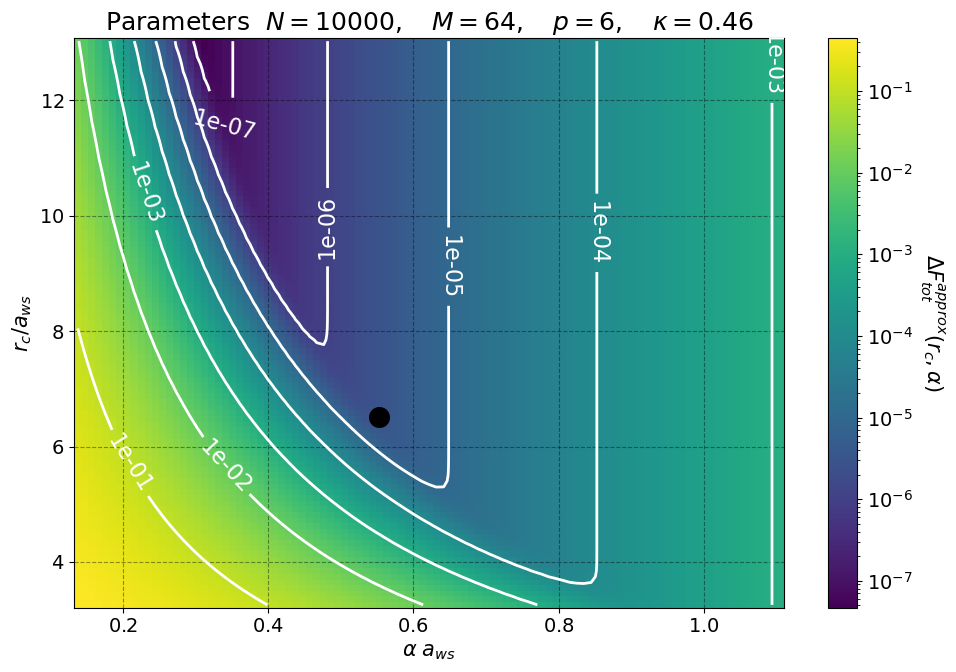

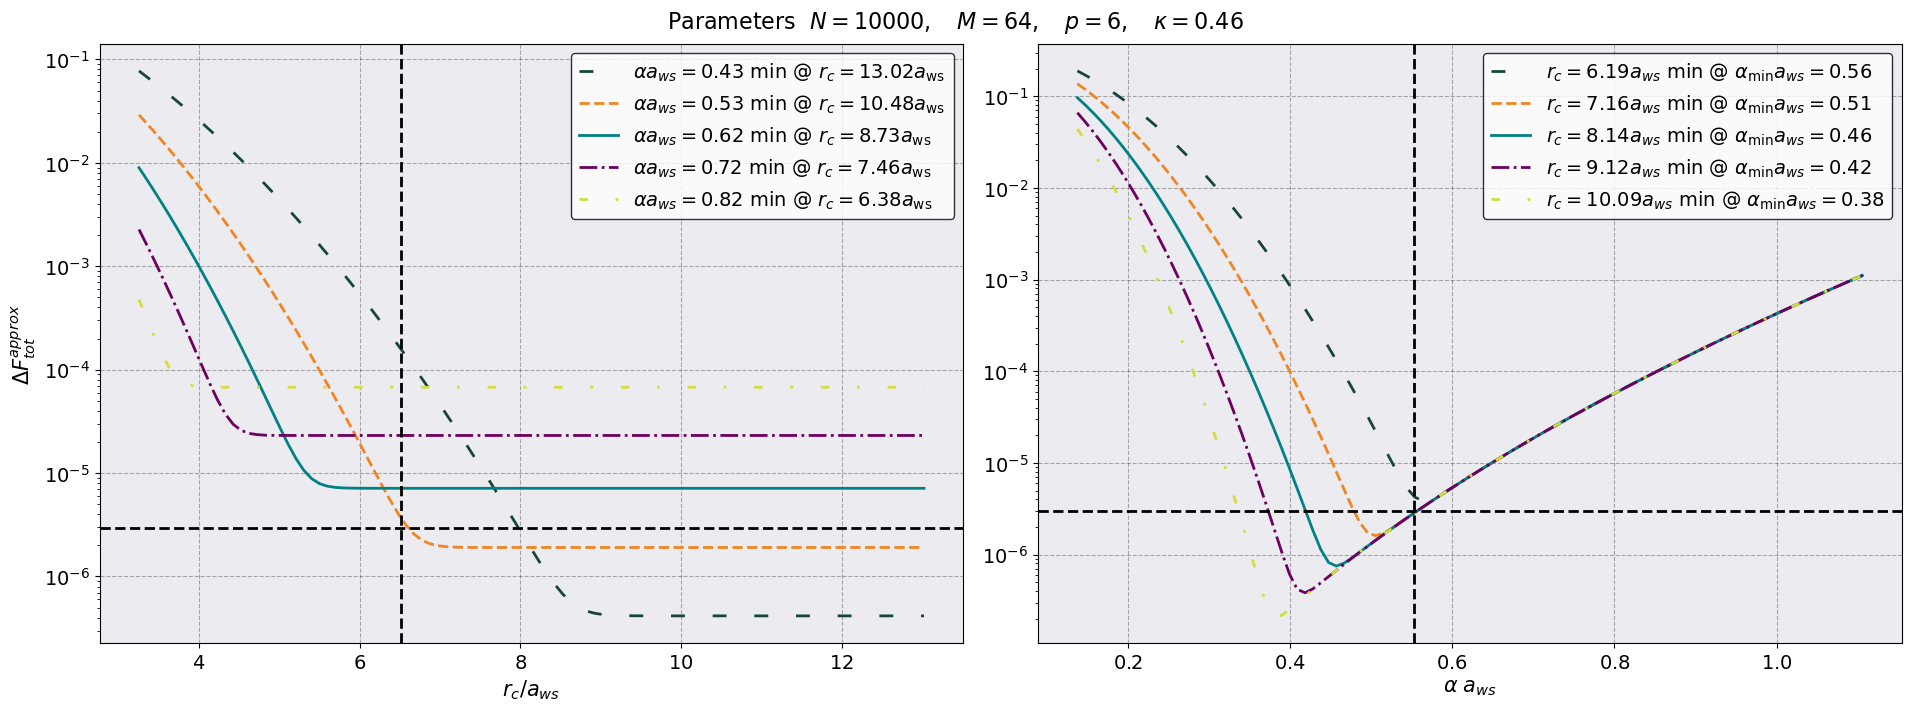

In [4]:
pre.run(pppm_estimate=True)

Testing PPPM parameter combinations:   0%|          | 0/96 [00:00<?, ?it/s]


OPTIMAL PPPM CONFIGURATION:
  Target Error: 1.0000e-06
  Mesh: 80 | CAO: 7 | rc: 3.3830e-08
  Ewald alpha: 1.1824e+08 | Force Error: 6.8929e-07
  PP Time: 1.0276e-01 s | PM Time: 9.0548e-02 s
  Total Time: 1.9331e-01 s

Results saved to:
  Full parameter sweep data: SarkasSimulations/qsp_cgs/PreProcessing/TimingStudy_data_qsp_cgs.csv
  Pareto-optimal configurations: SarkasSimulations/qsp_cgs/PreProcessing/Pareto_optimal_PPPM_qsp_cgs.csv
  Visualizations: SarkasSimulations/qsp_cgs/PreProcessing/PPPM_Plots


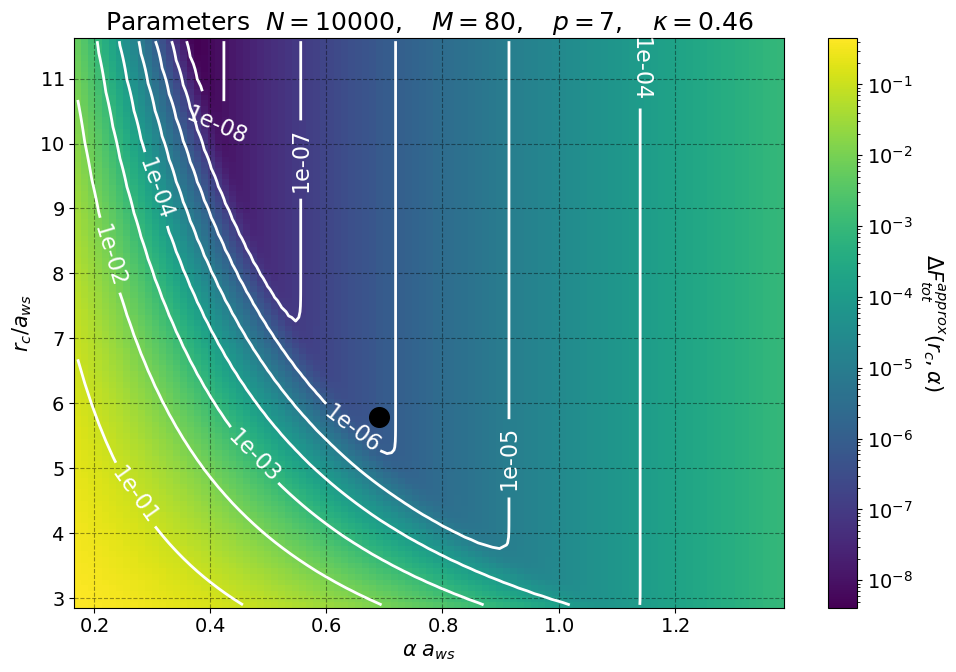

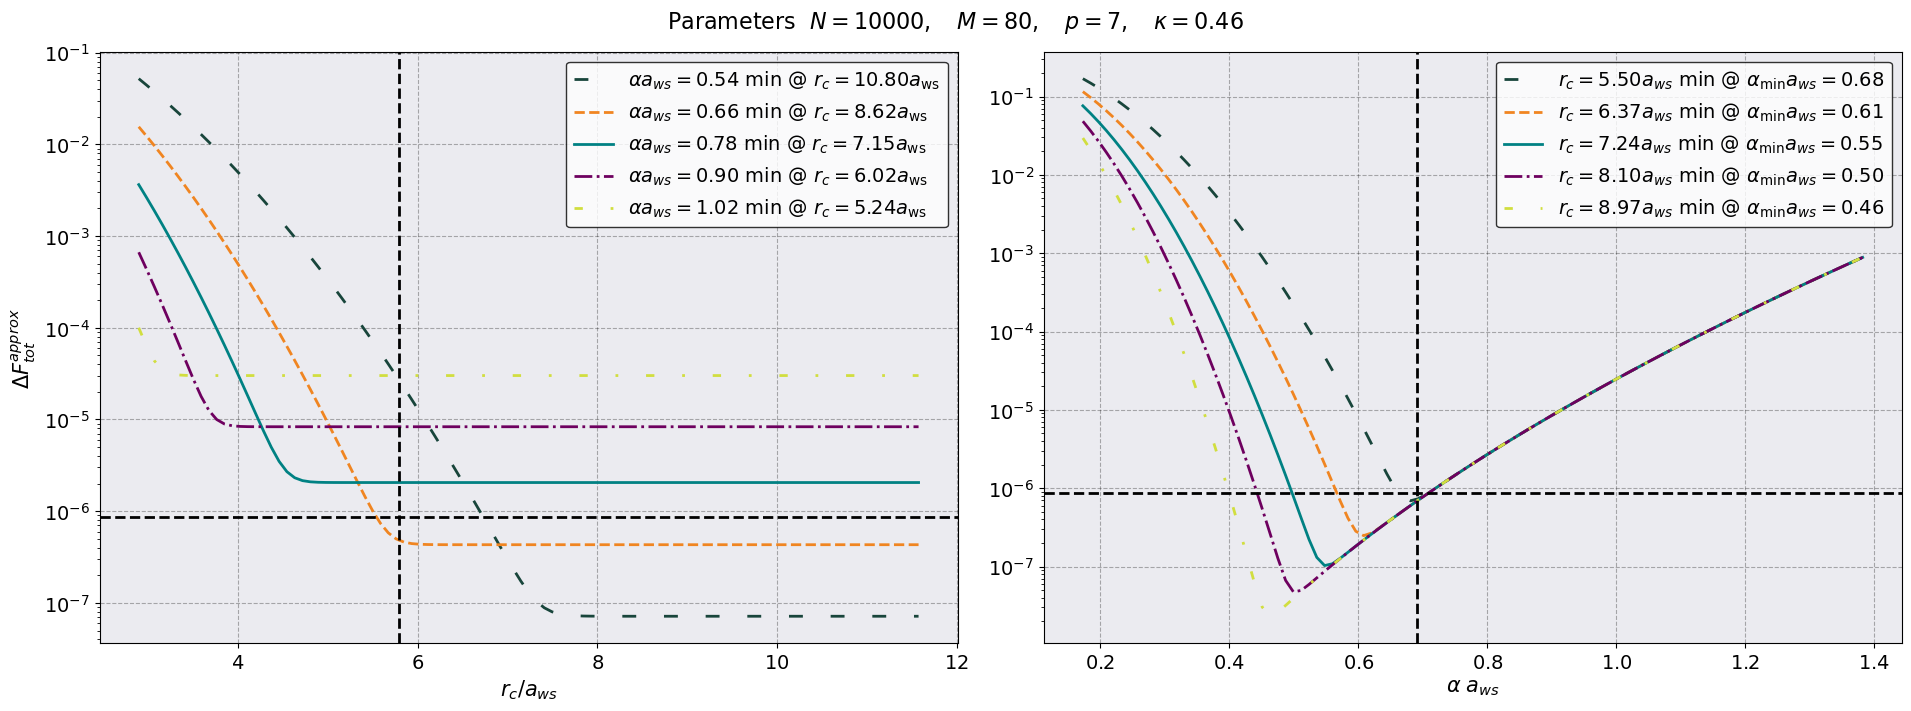

In [5]:
pp_cells = [3, 4, 5, 6]
pm_meshes = [32, 64, 80, 90, 100, 128,]
pm_caos = [4, 5, 6, 7]
pre.timing_study_calculation(
    target_error=1e-6,
    pp_cells=pp_cells,
    pm_meshes=pm_meshes,
    pm_caos=pm_caos,
)

In [6]:
pareto_points, best_point = pre.find_pareto_optimal_configs(target_error=1e-6)


OPTIMAL PPPM CONFIGURATION:
  Target Error: 1.0000e-06
  Mesh: 80 | CAO: 7 | rc: 3.3830e-08
  Ewald alpha: 1.1824e+08 | Force Error: 6.8929e-07
  PP Time: 1.0276e-01 s | PM Time: 9.0548e-02 s
  Total Time: 1.9331e-01 s


In [7]:
postproc = PostProcess(input_file_name)
postproc.setup(read_yaml=True)

FileNotFoundError: [Errno 2] No such file or directory: 'SarkasSimulations/qsp_cgs/Simulation/parameters.pickle'

In [ ]:
# Equilibration check
from sarkas.tools.observables import Thermodynamics

therm = Thermodynamics()
therm.setup(postproc.parameters, phase = "equilibration")
therm.temp_energy_plot(postproc, )

In [ ]:
# Production check
therm = Thermodynamics()
therm.setup(postproc.parameters)
therm.temp_energy_plot(postproc)

In [ ]:
# Radial Distribution Function 
from sarkas.tools.observables import RadialDistributionFunction

rdf = RadialDistributionFunction()
rdf.setup(postproc.parameters)
rdf.compute()
# Grab HNC data for comparison
# hnc_r, hnc_gee, hnc_gei, hnc_gii = np.loadtxt('hnc_gall.out', unpack=True)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,7))
# ax.plot(hnc_r , hnc_gee, label = 'hnc e-e RDF')
# ax.plot(hnc_r , hnc_gei, label = 'hnc e-p RDF')
# ax.plot(hnc_r , hnc_gii, label = 'hnc p-p RDF')
rdf.plot(scaling = postproc.species[0].a_ws, 
                  y = [('e-e RDF', "Mean"),
                       ('e-p RDF', "Mean"),
                       ('p-p RDF', "Mean")
                      ],
                  ax = ax, 
                  ls = '--')
ax.legend()
ax.set(xlim = (-0.2, 6), xlabel = r'$r/a_e$', ylabel = r"$g(r)$")

In [ ]:
from sarkas.tools.observables import ElectricCurrent
from sarkas.tools.transport import TransportCoefficients

In [ ]:
ec = ElectricCurrent()
ec.setup(postproc.parameters, no_slices = 4)
#ec.compute()
ec.parse()


In [ ]:
ec.dataframe

In [ ]:
tc = TransportCoefficients(postproc.parameters)
tc.electrical_conductivity(ec, "ElectricalConductivity")

In [ ]:
tc.conductivity_df

In [ ]:
rescaling = 1.0/ec.total_plasma_frequency
fig, ax = plt.subplots(1,1, figsize=(10,7))
ax.plot(tc.conductivity_df["Time"].iloc[:,0]*1e15, 
        tc.conductivity_df[("Electrical Conductivity", "Mean")] * rescaling,
       label = r'$\sigma$')

ax.plot(tc.conductivity_df["Time"].iloc[:,0]*1e15, tc.conductivity_df[("Electrical Conductivity", "Mean")].expanding().mean() * rescaling,
        ls = '--', label = r'Mov Avg')

ax.legend(ncol = 2)
ax.set(xlabel = r"$\tau$ [fs]",ylabel = r" $\sigma/\omega_p$")